In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from AT_plots import create_polar_plot

In [8]:
#sns.set_style('darkgrid')
sns.set_context('paper')#,rc={'figure.figsize':(6,3)})
plt.rcParams['figure.figsize'] = (6,6) #width, height
plt.rcParams['figure.titlesize'] = 20
plt.rcParams['font.size'] = 15

sns.set_theme(style = 'dark')
sns.set(font_scale=3)

In [9]:
Trim_all = pd.read_csv("RealAnts_ALL_TRIM.csv")
TrimNG_all = pd.read_csv("RealAnts_ALL_TRIMNG.csv")

/tmp/ipykernel_317661/3176302761.py:1: DtypeWarning: Columns (4,10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  Trim_all = pd.read_csv("RealAnts_ALL_TRIM.csv")
/tmp/ipykernel_317661/3176302761.py:2: DtypeWarning: Columns (4,10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  TrimNG_all = pd.read_csv("RealAnts_ALL_TRIMNG.csv")


In [10]:
# Wigwam 

wig_onR1 = "Wigwam_On-route 1 ZV.csv"
wig_offR1 = "Wigwam_Off-route 1 ZV.csv"
wig_onR2 = "Wigwam_On-route 2 ZV.csv"
wig_unfZV ="Wigwam_Unfamiliar ZV.csv"
wig_unfFV = "Wigwam_Unfamiliar FV.csv"

wig_onR1_df = pd.read_csv(wig_onR1)
wig_offR1_df = pd.read_csv(wig_offR1)
wig_onR2_df = pd.read_csv(wig_onR2)
wig_unfZV_df = pd.read_csv(wig_unfZV)
wig_unfFV_df = pd.read_csv(wig_unfFV)

# NewNest
newN_onR1ZV = "NewNest_On-route 1 ZV.csv"
newN_offR1ZV = "NewNest_Off-route 1 ZV.csv"
newN_onR1bZV = "NewNest_On-route 1B ZV.csv"
newN_onR2ZV = "NewNest_On-route 2 ZV.csv"
newN_unfZV = "NewNest_Unfamiliar ZV.csv"
newN_unfFV = "NewNest_Unfamiliar FV.csv"
newN_unfZV2 = "NewNest_Unfamiliar ZV 2.csv"
newN_unfZV3 = "NewNest_Unfamiliar ZV 3.csv"
newN_OR0 = "NewNest_Route 0m ZV.csv"
newN_OR3m = "NewNest_Plus 3m ZV.csv"

newN_onR1ZV_df = pd.read_csv(newN_onR1ZV)
newN_offR1ZV_df = pd.read_csv(newN_offR1ZV)
newN_onR1bZV_df = pd.read_csv(newN_onR1bZV)

newN_onR2ZV_df = pd.read_csv(newN_onR2ZV)

newN_unfZV_df = pd.read_csv(newN_unfZV)
newN_unfFV_df = pd.read_csv(newN_unfFV)
newN_unfZV2_df = pd.read_csv(newN_unfZV2)
newN_unfZV3_df = pd.read_csv(newN_unfZV3)

newN_OR0_df = pd.read_csv(newN_OR0)
newN_OR3m_df = pd.read_csv(newN_OR3m)


In [11]:
wig_main = pd.concat([wig_onR1_df, wig_offR1_df, wig_onR2_df, wig_unfZV_df, wig_unfFV_df], ignore_index=True)
NewN_main = pd.concat([newN_onR1ZV_df, newN_offR1ZV_df, newN_onR2ZV_df, newN_unfZV_df, newN_unfFV_df], ignore_index=True)

NewN_ONR = pd.concat([newN_onR1bZV_df, newN_onR1ZV_df, newN_OR0_df], ignore_index=True) #newN_offR1ZV_df

WigNew_ONR = pd.concat([wig_onR1_df], ignore_index=True)

both_ONR = pd.concat([WigNew_ONR, NewN_ONR], ignore_index=True)

NewN_ONROFR = pd.concat([newN_onR1ZV_df, newN_offR1ZV_df, newN_onR1bZV_df, newN_OR0_df, newN_OR3m_df], ignore_index=True)

both_main = pd.concat([wig_main, NewN_main], ignore_index=True)

both_all = pd.concat([wig_main, NewN_main, newN_onR1bZV_df, newN_OR0_df, newN_OR3m_df, newN_unfZV2_df, newN_unfZV3_df], ignore_index=True)

distant_only = pd.concat([wig_unfZV_df, wig_unfFV_df, newN_unfZV_df, newN_unfFV_df, newN_unfZV2_df, newN_unfZV3_df],  ignore_index=True)

In [12]:
print(list(both_main))
both_main = both_main.drop(columns=['Unnamed: 0'])
both_main = both_main.replace('Wigwam', 'Nest1')
both_main = both_main.replace('NewNest', 'Nest2')

# ['Unfamiliar ZV', 'Unfamiliar FV', 'Unfamiliar ZV 2', 'Unfamiliar ZV 3']
both_main = both_main.replace('Unfamiliar ZV', 'Distant ZV')
both_main = both_main.replace('Unfamiliar FV', 'Distant FV')
both_main = both_main.replace('Unfamiliar ZV 2', 'Distant ZV 2')
both_main = both_main.replace('Unfamiliar ZV 3', 'Distant ZV 3')

both_main.head()

distant_only = distant_only.replace('Unfamiliar ZV', 'Distant ZV')
distant_only = distant_only.replace('Unfamiliar FV', 'Distant FV')
distant_only = distant_only.replace('Unfamiliar ZV 2', 'Distant ZV 2')
distant_only = distant_only.replace('Unfamiliar ZV 3', 'Distant ZV 3')

['Unnamed: 0', 'Nest', 'Condition', 'Ant ID', 'TrimStraightnessIndex', 'TrimNoGaps_CircR', 'TrimChunksCircR', 'TrimSpeedPerFrameNoGapsMean', 'TrimFinalPointRelToNest', 'TrimLengthTotalmm', 'TrimBeelinePath (mm)']


mean speed
strightness index
straightness Circ_r no gaps
straightness Circ_r  chunled path
total path length


In [13]:
palette_var2 = 'hot'#'plasma'#'nipy_spectral'#'hot'#'nipy_spectral'
palette_var = 'cool'#'nipy_spectral' # 'plasma'

sns.set(font_scale=1)

# df Main

In [15]:
df = both_main

print(np.unique(df['Condition']))

print(list(df))

['Distant FV' 'Distant ZV' 'Off-route 1 ZV' 'On-route 1 ZV'
 'On-route 2 ZV']
['Nest', 'Condition', 'Ant ID', 'TrimStraightnessIndex', 'TrimNoGaps_CircR', 'TrimChunksCircR', 'TrimSpeedPerFrameNoGapsMean', 'TrimFinalPointRelToNest', 'TrimLengthTotalmm', 'TrimBeelinePath (mm)']


## MEan Speed

/tmp/ipykernel_127709/2421992381.py:13: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(y=y_var, x=x_var, data=df, palette=palette_var, scale='width', inner=None, split=True, hue='Nest')


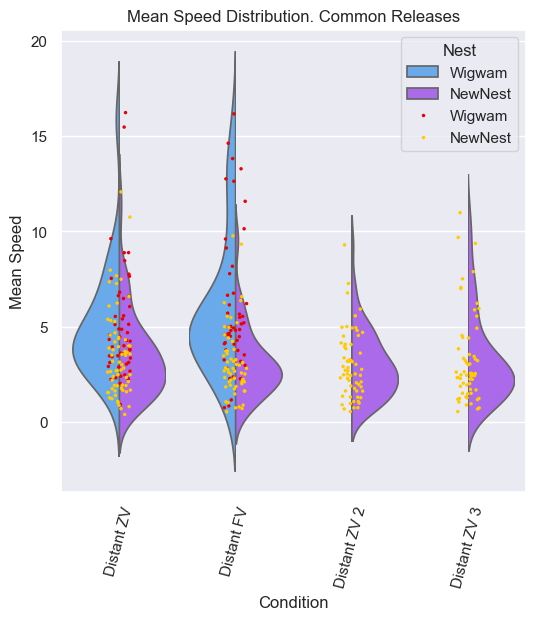

In [42]:
# TrimLengthTotalmm

import seaborn.objects as so


x_var = 'Condition'
y_var = 'TrimSpeedPerFrameNoGapsMean'
y_label = 'Mean Speed'
title = "Mean Speed Distribution. Common Releases"

sns.set(font_scale=1)

ax = sns.violinplot(y=y_var, x=x_var, data=df, palette=palette_var, scale='width', inner=None, split=True, hue='Nest')


xlim= ax.get_xlim()
ylim = ax.get_ylim()

for violin in ax.collections:
    bbox=violin.get_paths()[0].get_extents()
    x0, y0, width, height = bbox.bounds
    violin.set_clip_path(plt.Rectangle((x0, y0), width, height, transform=ax.transData)) # height /2


sns.stripplot(y=y_var, x = x_var, data= df,  palette = palette_var2, size=2.5, hue='Nest')

ax.tick_params(axis='x', rotation=75) #, size=25


ax.set_xlim(xlim)
ax.set_ylim(ylim)

ax.set_xlabel('Condition')
ax.set_ylabel(y_label)

plt.title(title)
plt.show()
plt.show()

## straightness Index

/tmp/ipykernel_127709/3816388665.py:12: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(y=y_var, x=x_var, data=df, palette=palette_var, scale='width', inner=None, split=True, hue='Nest')


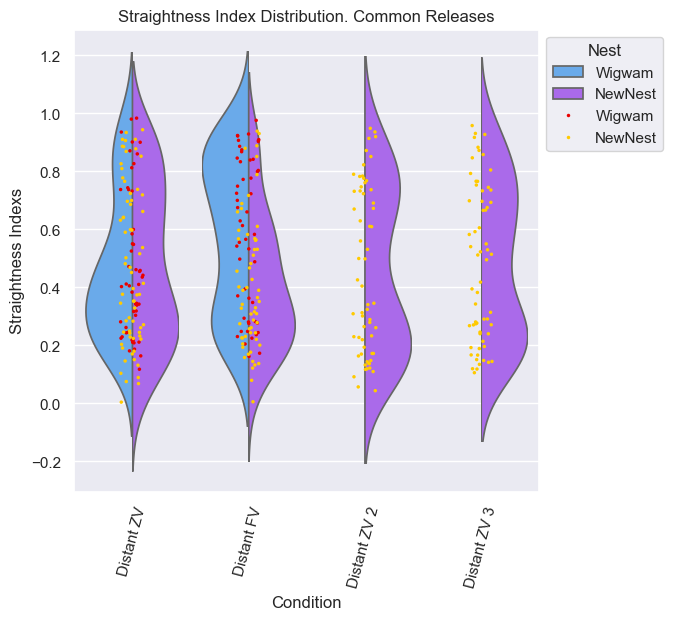

In [30]:
# TrimLengthTotalmm



x_var = 'Condition'
y_var = 'TrimStraightnessIndex'
y_label = 'Straightness Indexs'
title = "Straightness Index Distribution. Common Releases"

sns.set(font_scale=1)

ax = sns.violinplot(y=y_var, x=x_var, data=df, palette=palette_var, scale='width', inner=None, split=True, hue='Nest')


xlim= ax.get_xlim()
ylim = ax.get_ylim()

for violin in ax.collections:
    bbox=violin.get_paths()[0].get_extents()
    x0, y0, width, height = bbox.bounds
    violin.set_clip_path(plt.Rectangle((x0, y0), width, height, transform=ax.transData)) # height /2


sns.stripplot(y=y_var, x = x_var, data= df,  palette = palette_var2, size=2.5, hue='Nest')

ax.tick_params(axis='x', rotation=75) #, size=25

sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))


ax.set_xlim(xlim)
ax.set_ylim(ylim)

ax.set_xlabel('Condition')
ax.set_ylabel(y_label)

plt.title(title)

plt.show()
plt.show()

## Straightness Circ_r No Gaps

/tmp/ipykernel_127709/520554884.py:12: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(y=y_var, x=x_var, data=df, palette=palette_var, scale='width', inner=None, split=True, hue='Nest')


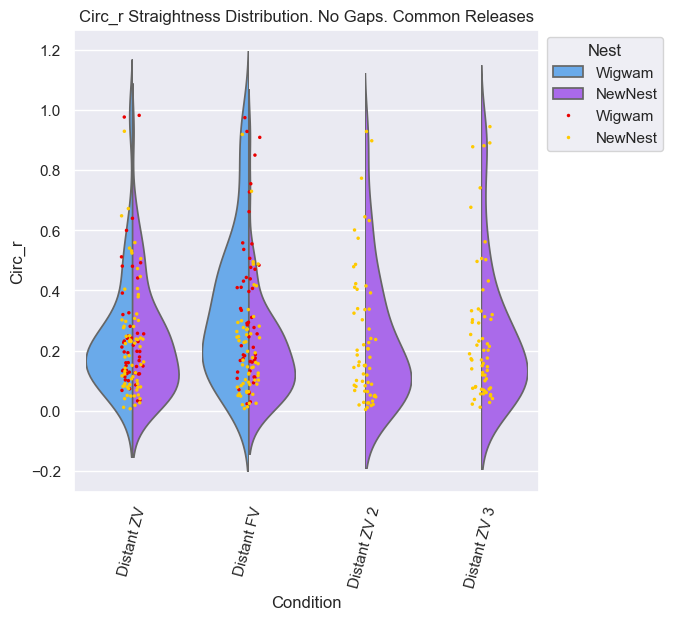

In [34]:
# TrimLengthTotalmm



x_var = 'Condition'
y_var = 'TrimNoGaps_CircR'
y_label = 'Circ_r'
title = "Circ_r Straightness Distribution. No Gaps. Common Releases"

sns.set(font_scale=1)

ax = sns.violinplot(y=y_var, x=x_var, data=df, palette=palette_var, scale='width', inner=None, split=True, hue='Nest')


xlim= ax.get_xlim()
ylim = ax.get_ylim()

for violin in ax.collections:
    bbox=violin.get_paths()[0].get_extents()
    x0, y0, width, height = bbox.bounds
    violin.set_clip_path(plt.Rectangle((x0, y0), width, height, transform=ax.transData)) # height /2


sns.stripplot(y=y_var, x = x_var, data= df,  palette = palette_var2, size=2.5, hue='Nest')

ax.tick_params(axis='x', rotation=75) #, size=25

sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))


ax.set_xlim(xlim)
ax.set_ylim(ylim)

ax.set_xlabel('Condition')
ax.set_ylabel(y_label)

plt.title(title)

plt.show()
plt.show()

## straightness Circ_r  Chunked

/tmp/ipykernel_127709/2798106761.py:12: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(y=y_var, x=x_var, data=df, palette=palette_var, scale='width', inner=None, split=True, hue='Nest')


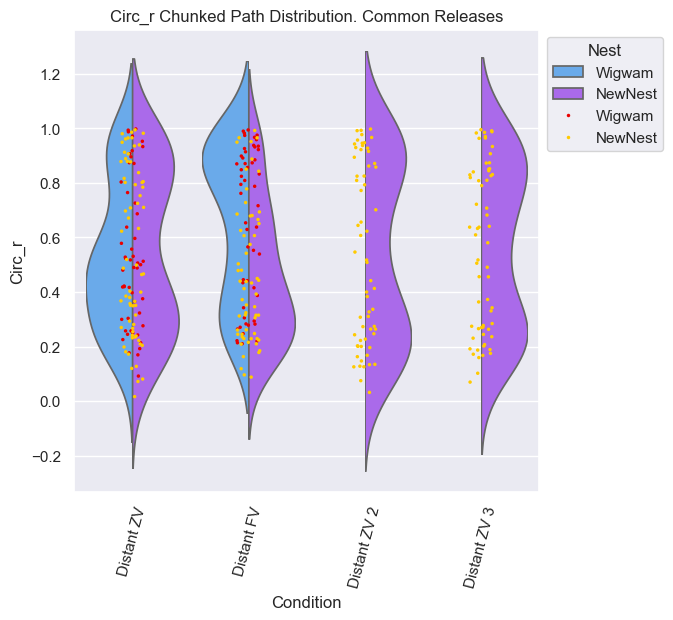

In [33]:
# TrimLengthTotalmm



x_var = 'Condition'
y_var = 'TrimChunksCircR'
y_label = 'Circ_r'
title = "Circ_r Chunked Path Distribution. Common Releases"

sns.set(font_scale=1)

ax = sns.violinplot(y=y_var, x=x_var, data=df, palette=palette_var, scale='width', inner=None, split=True, hue='Nest')


xlim= ax.get_xlim()
ylim = ax.get_ylim()

for violin in ax.collections:
    bbox=violin.get_paths()[0].get_extents()
    x0, y0, width, height = bbox.bounds
    violin.set_clip_path(plt.Rectangle((x0, y0), width, height, transform=ax.transData)) # height /2


sns.stripplot(y=y_var, x = x_var, data= df,  palette = palette_var2, size=2.5, hue='Nest')

ax.tick_params(axis='x', rotation=75) #, size=25

sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))


ax.set_xlim(xlim)
ax.set_ylim(ylim)

ax.set_xlabel('Condition')
ax.set_ylabel(y_label)

plt.title(title)

plt.show()
plt.show()

## total path length

/tmp/ipykernel_127709/2982438422.py:14: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(y=y_var, x=x_var, data=df, palette=palette_var, scale='width', inner=None, split=True, hue='Nest')


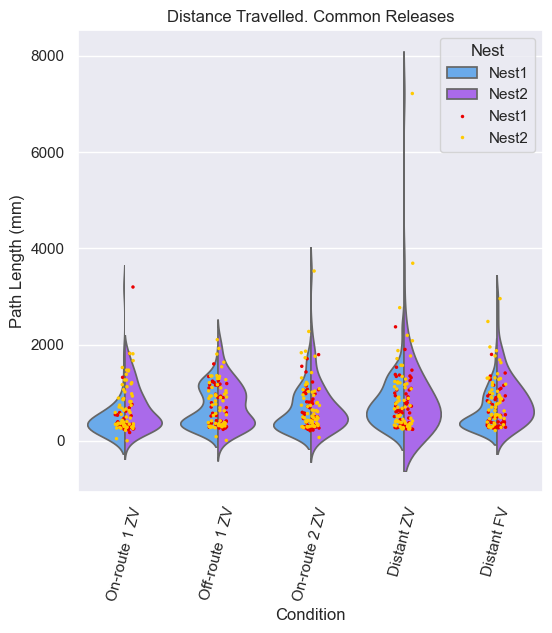

In [13]:
# TrimLengthTotalmm

# TrimLengthTotalmm



x_var = 'Condition'
y_var = 'TrimLengthTotalmm'
y_label = 'Path Length (mm)'
title = "Distance Travelled. Common Releases"

sns.set(font_scale=1)

ax = sns.violinplot(y=y_var, x=x_var, data=df, palette=palette_var, scale='width', inner=None, split=True, hue='Nest')


xlim= ax.get_xlim()
ylim = ax.get_ylim()

for violin in ax.collections:
    bbox=violin.get_paths()[0].get_extents()
    x0, y0, width, height = bbox.bounds
    violin.set_clip_path(plt.Rectangle((x0, y0), width, height, transform=ax.transData)) # height /2


sns.stripplot(y=y_var, x = x_var, data= df,  palette = palette_var2, size=2.5, hue='Nest')

ax.tick_params(axis='x', rotation=75) #, size=25


ax.set_xlim(xlim)
ax.set_ylim(ylim)

ax.set_xlabel('Condition')
ax.set_ylabel(y_label)

plt.title(title)

plt.show()
plt.show()

# both_ONR

In [14]:
df = both_ONR

print(list(both_ONR))

['Unnamed: 0', 'Nest', 'Condition', 'Ant ID', 'TrimStraightnessIndex', 'TrimNoGaps_CircR', 'TrimChunksCircR', 'TrimSpeedPerFrameNoGapsMean', 'TrimFinalPointRelToNest', 'TrimLengthTotalmm', 'TrimBeelinePath (mm)']


In [15]:
#both_ONR = both_ONR.drop('U')

## mean speed

/tmp/ipykernel_127709/3774090875.py:12: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(y=y_var, x=x_var, data=df, palette=palette_var, scale='width', inner=None, split=True, hue='Nest')


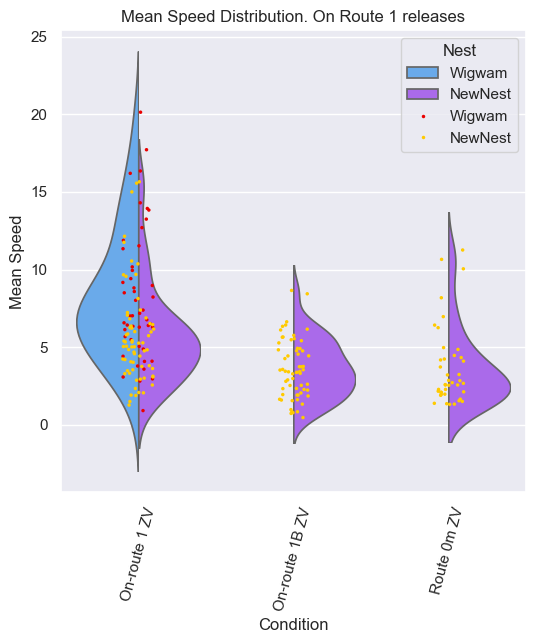

In [16]:
# TrimLengthTotalmm



x_var = 'Condition'
y_var = 'TrimSpeedPerFrameNoGapsMean'
y_label = 'Mean Speed'
title = "Mean Speed Distribution. On Route 1 releases"

sns.set(font_scale=1)

ax = sns.violinplot(y=y_var, x=x_var, data=df, palette=palette_var, scale='width', inner=None, split=True, hue='Nest')


xlim= ax.get_xlim()
ylim = ax.get_ylim()

for violin in ax.collections:
    bbox=violin.get_paths()[0].get_extents()
    x0, y0, width, height = bbox.bounds
    violin.set_clip_path(plt.Rectangle((x0, y0), width, height, transform=ax.transData)) # height /2


sns.stripplot(y=y_var, x = x_var, data= df,  palette = palette_var2, size=2.5, hue='Nest')

ax.tick_params(axis='x', rotation=75) #, size=25


ax.set_xlim(xlim)
ax.set_ylim(ylim)

ax.set_xlabel('Condition')
ax.set_ylabel(y_label)

plt.title(title)
plt.show()
plt.show()

## distance travlled

/tmp/ipykernel_127709/1543847687.py:12: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(y=y_var, x=x_var, data=df, palette=palette_var, scale='width', inner=None, split=True, hue='Nest')


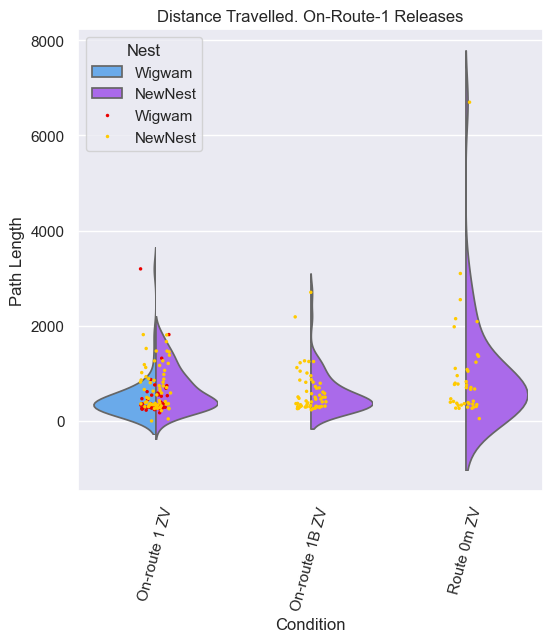

In [17]:
# TrimLengthTotalmm



x_var = 'Condition'
y_var = 'TrimLengthTotalmm'
y_label = 'Path Length'
title = "Distance Travelled. On-Route-1 Releases"

sns.set(font_scale=1)

ax = sns.violinplot(y=y_var, x=x_var, data=df, palette=palette_var, scale='width', inner=None, split=True, hue='Nest')


xlim= ax.get_xlim()
ylim = ax.get_ylim()

for violin in ax.collections:
    bbox=violin.get_paths()[0].get_extents()
    x0, y0, width, height = bbox.bounds
    violin.set_clip_path(plt.Rectangle((x0, y0), width, height, transform=ax.transData)) # height /2


sns.stripplot(y=y_var, x = x_var, data= df,  palette = palette_var2, size=2.5, hue='Nest')

ax.tick_params(axis='x', rotation=75) #, size=25


ax.set_xlim(xlim)
ax.set_ylim(ylim)

ax.set_xlabel('Condition')
ax.set_ylabel(y_label)

plt.title(title)
plt.show()
plt.show()

## Straightness index

/tmp/ipykernel_127709/2012439367.py:12: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(y=y_var, x=x_var, data=df, palette=palette_var, scale='width', inner=None, split=True, hue='Nest')


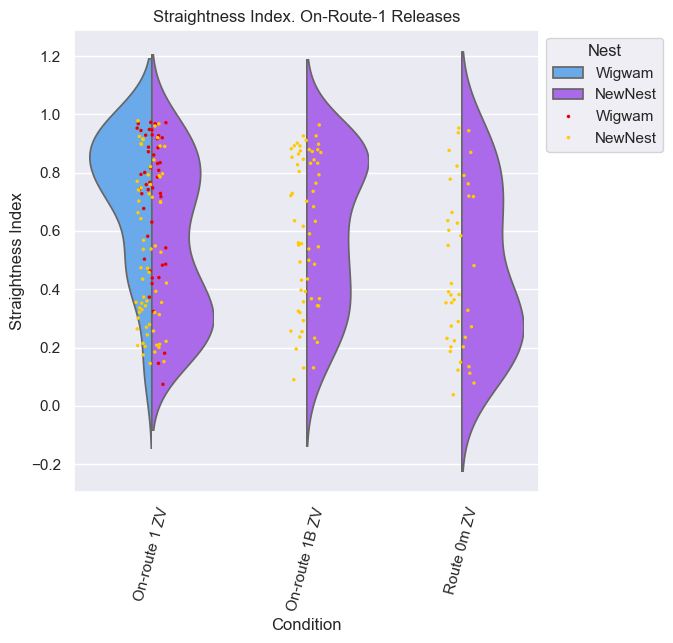

In [18]:
# TrimLengthTotalmm



x_var = 'Condition'
y_var = 'TrimStraightnessIndex'
y_label = 'Straightness Index'
title = "Straightness Index. On-Route-1 Releases"

sns.set(font_scale=1)

ax = sns.violinplot(y=y_var, x=x_var, data=df, palette=palette_var, scale='width', inner=None, split=True, hue='Nest')


xlim= ax.get_xlim()
ylim = ax.get_ylim()

for violin in ax.collections:
    bbox=violin.get_paths()[0].get_extents()
    x0, y0, width, height = bbox.bounds
    violin.set_clip_path(plt.Rectangle((x0, y0), width, height, transform=ax.transData)) # height /2


sns.stripplot(y=y_var, x = x_var, data= df,  palette = palette_var2, size=2.5, hue='Nest')

ax.tick_params(axis='x', rotation=75) #, size=25

sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))


ax.set_xlim(xlim)
ax.set_ylim(ylim)

ax.set_xlabel('Condition')
ax.set_ylabel(y_label)

plt.title(title)
plt.show()
plt.show()

## circ_r ng

/tmp/ipykernel_127709/3589150706.py:12: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(y=y_var, x=x_var, data=df, palette=palette_var, scale='width', inner=None, split=True, hue='Nest')


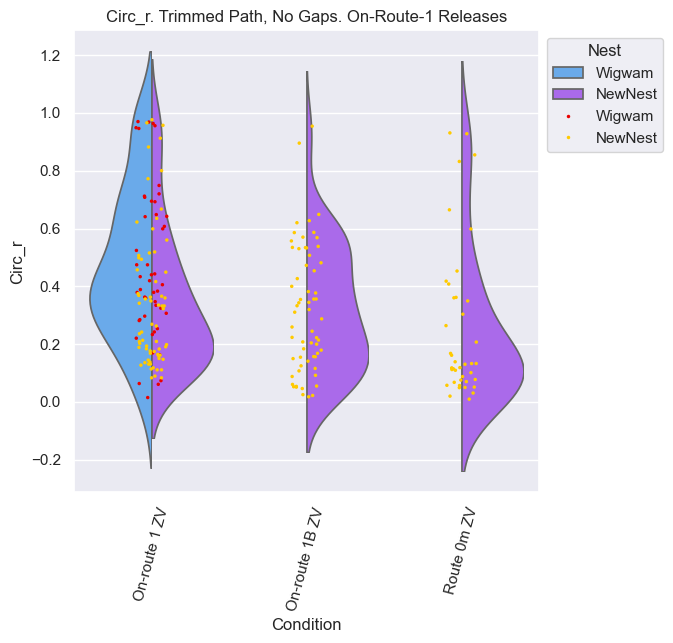

In [19]:
# TrimLengthTotalmm



x_var = 'Condition'
y_var = 'TrimNoGaps_CircR'
y_label = 'Circ_r'
title = "Circ_r. Trimmed Path, No Gaps. On-Route-1 Releases"

sns.set(font_scale=1)

ax = sns.violinplot(y=y_var, x=x_var, data=df, palette=palette_var, scale='width', inner=None, split=True, hue='Nest')


xlim= ax.get_xlim()
ylim = ax.get_ylim()

for violin in ax.collections:
    bbox=violin.get_paths()[0].get_extents()
    x0, y0, width, height = bbox.bounds
    violin.set_clip_path(plt.Rectangle((x0, y0), width, height, transform=ax.transData)) # height /2


sns.stripplot(y=y_var, x = x_var, data= df,  palette = palette_var2, size=2.5, hue='Nest')

ax.tick_params(axis='x', rotation=75) #, size=25

sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

ax.set_xlim(xlim)
ax.set_ylim(ylim)

ax.set_xlabel('Condition')
ax.set_ylabel(y_label)

plt.title(title)
plt.show()
plt.show()

## circ_r chunk

/tmp/ipykernel_127709/102680640.py:8: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(y=y_var, x=x_var, data=df, palette=palette_var, scale='width', inner=None, split=True, hue='Nest')


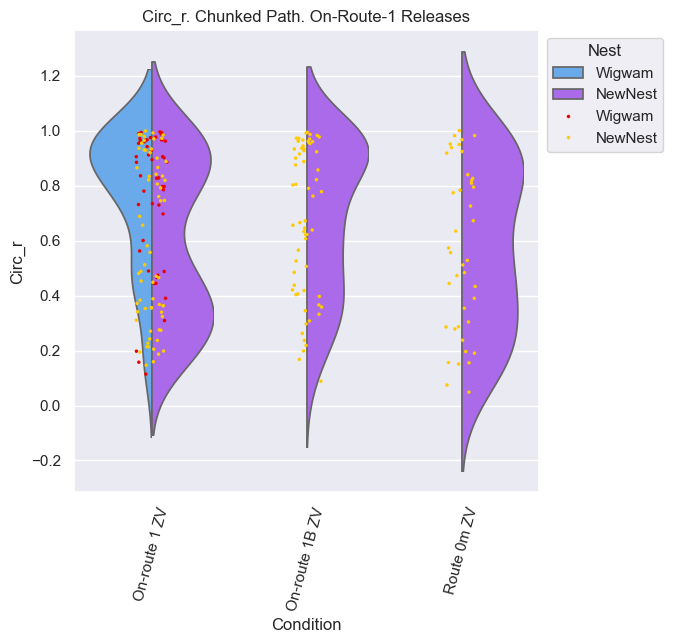

In [20]:


x_var = 'Condition'
y_var = 'TrimChunksCircR'
y_label = 'Circ_r'
title = "Circ_r. Chunked Path. On-Route-1 Releases"

sns.set(font_scale=1)

ax = sns.violinplot(y=y_var, x=x_var, data=df, palette=palette_var, scale='width', inner=None, split=True, hue='Nest')


xlim= ax.get_xlim()
ylim = ax.get_ylim()

for violin in ax.collections:
    bbox=violin.get_paths()[0].get_extents()
    x0, y0, width, height = bbox.bounds
    violin.set_clip_path(plt.Rectangle((x0, y0), width, height, transform=ax.transData)) # height /2


sns.stripplot(y=y_var, x = x_var, data= df,  palette = palette_var2, size=2.5, hue='Nest')

ax.tick_params(axis='x', rotation=75) #, size=25

sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

ax.set_xlim(xlim)
ax.set_ylim(ylim)

ax.set_xlabel('Condition')
ax.set_ylabel(y_label)

plt.title(title)
plt.show()
plt.show()

# df  Unfams

In [21]:
df = distant_only
#df = df.drop('Unnamed: 0', axis = 1)
print(list(df))

['Unnamed: 0', 'Nest', 'Condition', 'Ant ID', 'TrimStraightnessIndex', 'TrimNoGaps_CircR', 'TrimChunksCircR', 'TrimSpeedPerFrameNoGapsMean', 'TrimFinalPointRelToNest', 'TrimLengthTotalmm', 'TrimBeelinePath (mm)']


## Mean Speed

/tmp/ipykernel_127709/2106229932.py:12: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(y=y_var, x=x_var, data=df, palette=palette_var, scale='width', inner=None, split=True, hue='Nest')


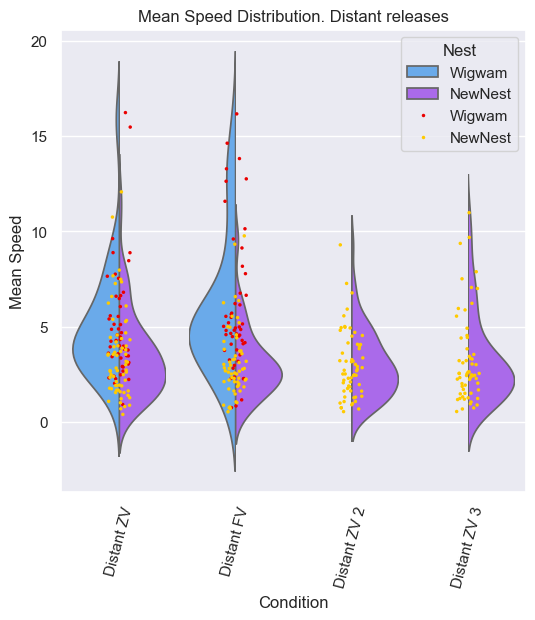

In [22]:
# TrimLengthTotalmm



x_var = 'Condition'
y_var = 'TrimSpeedPerFrameNoGapsMean'
y_label = 'Mean Speed'
title = "Mean Speed Distribution. Distant releases"

sns.set(font_scale=1)

ax = sns.violinplot(y=y_var, x=x_var, data=df, palette=palette_var, scale='width', inner=None, split=True, hue='Nest')


xlim= ax.get_xlim()
ylim = ax.get_ylim()

for violin in ax.collections:
    bbox=violin.get_paths()[0].get_extents()
    x0, y0, width, height = bbox.bounds
    violin.set_clip_path(plt.Rectangle((x0, y0), width, height, transform=ax.transData)) # height /2


sns.stripplot(y=y_var, x = x_var, data= df,  palette = palette_var2, size=2.5, hue='Nest')

ax.tick_params(axis='x', rotation=75) #, size=25


ax.set_xlim(xlim)
ax.set_ylim(ylim)

ax.set_xlabel('Condition')
ax.set_ylabel(y_label)

plt.title(title)
plt.show()
plt.show()

## Path Length

/tmp/ipykernel_127709/4256460442.py:12: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(y=y_var, x=x_var, data=df, palette=palette_var, scale='width', inner=None, split=True, hue='Nest')


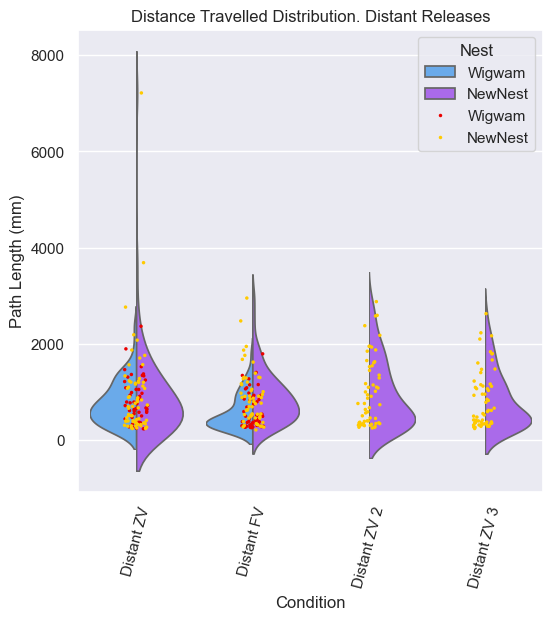

In [23]:
# TrimLengthTotalmm



x_var = 'Condition'
y_var = 'TrimLengthTotalmm'
y_label = 'Path Length (mm)'
title = "Distance Travelled Distribution. Distant Releases"

sns.set(font_scale=1)

ax = sns.violinplot(y=y_var, x=x_var, data=df, palette=palette_var, scale='width', inner=None, split=True, hue='Nest')


xlim= ax.get_xlim()
ylim = ax.get_ylim()

for violin in ax.collections:
    bbox=violin.get_paths()[0].get_extents()
    x0, y0, width, height = bbox.bounds
    violin.set_clip_path(plt.Rectangle((x0, y0), width, height, transform=ax.transData)) # height /2


sns.stripplot(y=y_var, x = x_var, data= df,  palette = palette_var2, size=2.5, hue='Nest')

ax.tick_params(axis='x', rotation=75) #, size=25


ax.set_xlim(xlim)
ax.set_ylim(ylim)

ax.set_xlabel('Condition')
ax.set_ylabel(y_label)

plt.title(title)
plt.show()
plt.show()

### Broken Axis

/tmp/ipykernel_317661/1698894651.py:20: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(y=y_var, x=x_var, data=df, palette=palette_var, scale='width', inner=None, split=True, hue='Nest', ax= axa)
/tmp/ipykernel_317661/1698894651.py:21: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(y=y_var, x=x_var, data=df, palette=palette_var, scale='width', inner=None, split=True, hue='Nest', ax=axb)


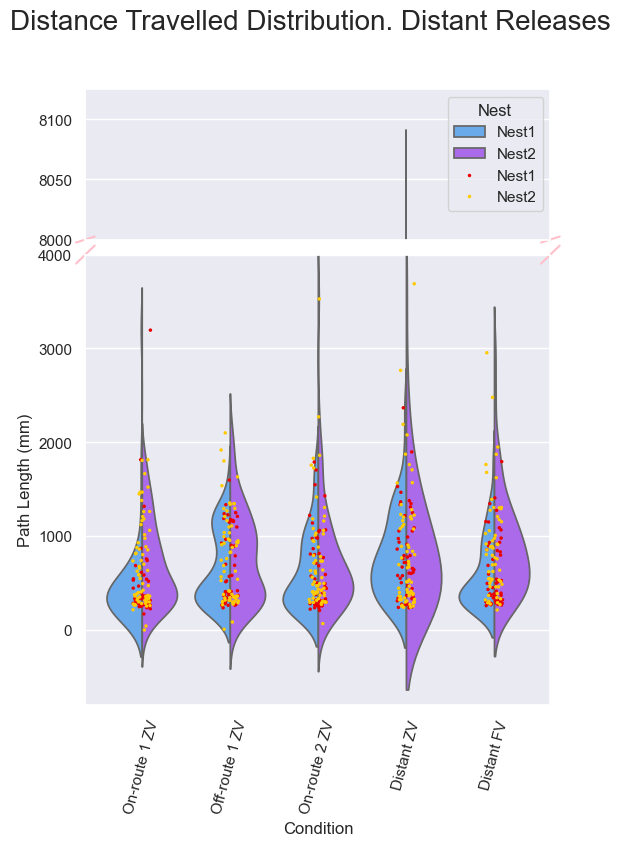

In [74]:
# TrimLengthTotalmm
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

x_var = 'Condition'
y_var = 'TrimLengthTotalmm'

y_label = 'Path Length (mm)'
title = "Distance Travelled Distribution. Distant Releases"

sns.set(font_scale=1)

f = plt.figure(figsize=(6, 8))
gs = GridSpec(2, 1, height_ratios=[1, 3], hspace=0.05)
axa = f.add_subplot(gs[0])
axb = f.add_subplot(gs[1])

# Double plot, half n half
sns.violinplot(y=y_var, x=x_var, data=df, palette=palette_var, scale='width', inner=None, split=True, hue='Nest', ax= axa)
sns.violinplot(y=y_var, x=x_var, data=df, palette=palette_var, scale='width', inner=None, split=True, hue='Nest', ax=axb)

sns.stripplot(y=y_var, x = x_var, data= df,  palette = palette_var2, size=2.5, hue='Nest', ax=axa)
sns.stripplot(y=y_var, x = x_var, data= df,  palette = palette_var2, size=2.5, hue='Nest', ax=axb)

# set the ylims for each double plot
axa.set_ylim(8000, 8125) # top. values chosen based on this example
axb.set_ylim(-800, 4000) # bottom. 

#axa.get_xaxis().set_visable(False)
axa.set_ylabel("") # no messy lables
axb.set_ylabel("")
#axa.get_legend().remove()
axb.get_legend().remove() # only need one legend

axa.tick_params(
    axis='x',
    which='both',
    bottom=False,
    labelbottom=False
)

axb.tick_params(axis='x', rotation=75) #, size=25  slight diagonal for easey reading
d=0.02

# ticks to show axis break
kwargs = dict(transform=axa.transAxes, color='pink', clip_on=False)
axa.plot((-d, +d), (-d, +d), **kwargs)        # top-left diagonal
axa.plot((1 - d, 1 + d), (-d, +d), **kwargs)  # top-right diagonal
kwargs.update(transform=axb.transAxes)  # switch to the bottom axes
axb.plot((-d, +d), (1 - d, 1 + d), **kwargs)  # bottom-left diagonal
axb.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  # bottom-right diagonal

axa.set_xlabel('')
axb.set_ylabel(y_label)

plt.suptitle(title)
plt.show()
plt.show()

# Straightnrss Index

/tmp/ipykernel_127709/835996752.py:12: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(y=y_var, x=x_var, data=df, palette=palette_var, scale='width', inner=None, split=True, hue='Nest')


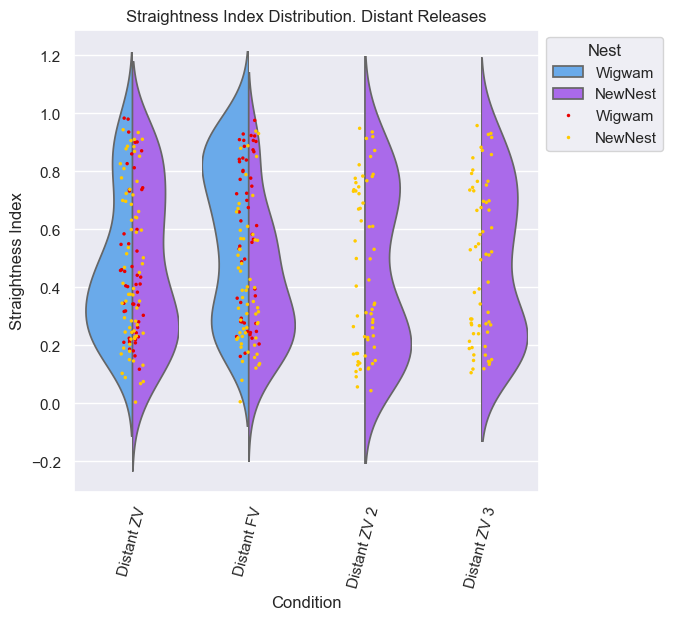

In [29]:
# TrimLengthTotalmm



x_var = 'Condition'
y_var = 'TrimStraightnessIndex'
y_label = 'Straightness Index'
title = "Straightness Index Distribution. Distant Releases"

sns.set(font_scale=1)

ax = sns.violinplot(y=y_var, x=x_var, data=df, palette=palette_var, scale='width', inner=None, split=True, hue='Nest')


xlim= ax.get_xlim()
ylim = ax.get_ylim()

for violin in ax.collections:
    bbox=violin.get_paths()[0].get_extents()
    x0, y0, width, height = bbox.bounds
    violin.set_clip_path(plt.Rectangle((x0, y0), width, height, transform=ax.transData)) # height /2


sns.stripplot(y=y_var, x = x_var, data= df,  palette = palette_var2, size=2.5, hue='Nest')

ax.tick_params(axis='x', rotation=75) #, size=25

sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))


ax.set_xlim(xlim)
ax.set_ylim(ylim)

ax.set_xlabel('Condition')
ax.set_ylabel(y_label)

plt.title(title)
plt.show()
plt.show()

## Straightness Circ_r No Gaps

/tmp/ipykernel_127709/546972311.py:12: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(y=y_var, x=x_var, data=df, palette=palette_var, scale='width', inner=None, split=True, hue='Nest')


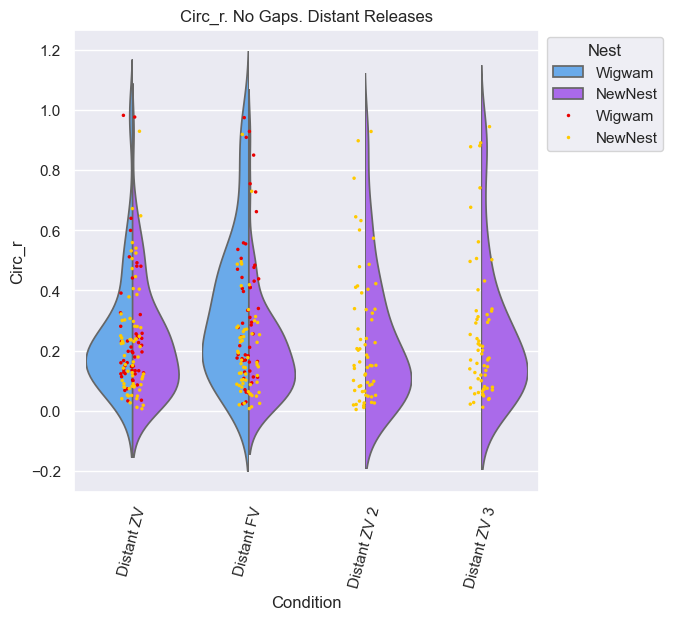

In [28]:
# TrimLengthTotalmm



x_var = 'Condition'
y_var = 'TrimNoGaps_CircR'
y_label = 'Circ_r'
title = "Circ_r. No Gaps. Distant Releases"

sns.set(font_scale=1)

ax = sns.violinplot(y=y_var, x=x_var, data=df, palette=palette_var, scale='width', inner=None, split=True, hue='Nest')


xlim= ax.get_xlim()
ylim = ax.get_ylim()

for violin in ax.collections:
    bbox=violin.get_paths()[0].get_extents()
    x0, y0, width, height = bbox.bounds
    violin.set_clip_path(plt.Rectangle((x0, y0), width, height, transform=ax.transData)) # height /2


sns.stripplot(y=y_var, x = x_var, data= df,  palette = palette_var2, size=2.5, hue='Nest')

ax.tick_params(axis='x', rotation=75) #, size=25

sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))


ax.set_xlim(xlim)
ax.set_ylim(ylim)

ax.set_xlabel('Condition')
ax.set_ylabel(y_label)

plt.title(title)
plt.show()
plt.show()

## Straightness Index Chunked

/tmp/ipykernel_127709/1335481334.py:12: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(y=y_var, x=x_var, data=df, palette=palette_var, scale='width', inner=None, split=True, hue='Nest')


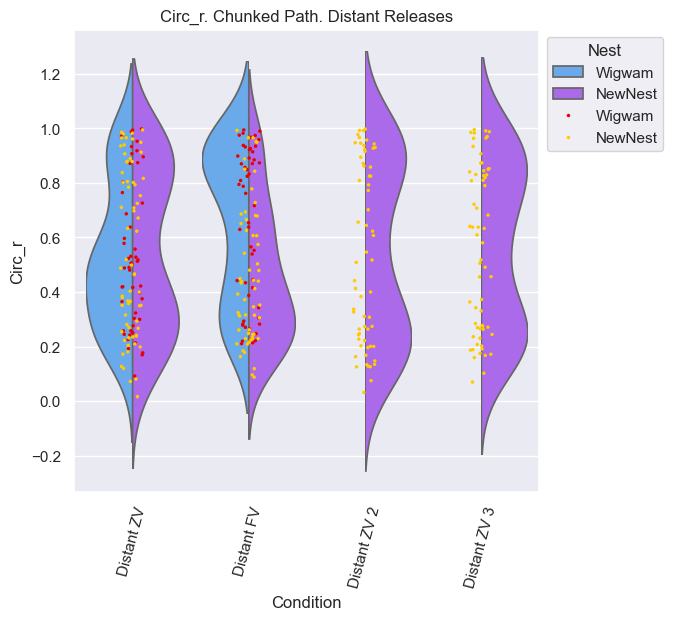

In [27]:
# TrimLengthTotalmm



x_var = 'Condition'
y_var = 'TrimChunksCircR'
y_label = 'Circ_r'
title = "Circ_r. Chunked Path. Distant Releases"

sns.set(font_scale=1)

ax = sns.violinplot(y=y_var, x=x_var, data=df, palette=palette_var, scale='width', inner=None, split=True, hue='Nest')


xlim= ax.get_xlim()
ylim = ax.get_ylim()

for violin in ax.collections:
    bbox=violin.get_paths()[0].get_extents()
    x0, y0, width, height = bbox.bounds
    violin.set_clip_path(plt.Rectangle((x0, y0), width, height, transform=ax.transData)) # height /2


sns.stripplot(y=y_var, x = x_var, data= df,  palette = palette_var2, size=2.5, hue='Nest')

ax.tick_params(axis='x', rotation=75) #, size=25

sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

ax.set_xlim(xlim)
ax.set_ylim(ylim)

ax.set_xlabel('Condition')
ax.set_ylabel(y_label)

plt.title(title)
plt.show()
plt.show()